In [22]:
import pandas as pd
df = pd.read_csv('/content/diminos_data.csv')
df.head()

,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


In [23]:
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])
df['order_delivered_at'] = pd.to_datetime(df['order_delivered_at'])
df['delivery_time'] = (df['order_delivered_at'] - df['order_placed_at']).dt.total_seconds() / 60


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            15000 non-null  int64         
 1   order_placed_at     15000 non-null  datetime64[ns]
 2   order_delivered_at  15000 non-null  datetime64[ns]
 3   delivery_time       15000 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(1)
memory usage: 468.9 KB


In [25]:
delivery_time_95th = df['delivery_time'].quantile(0.95)

print(f"The 95th percentile of delivery time is: {delivery_time_95th:.2f} minutes")

The 95th percentile of delivery time is: 27.26 minutes


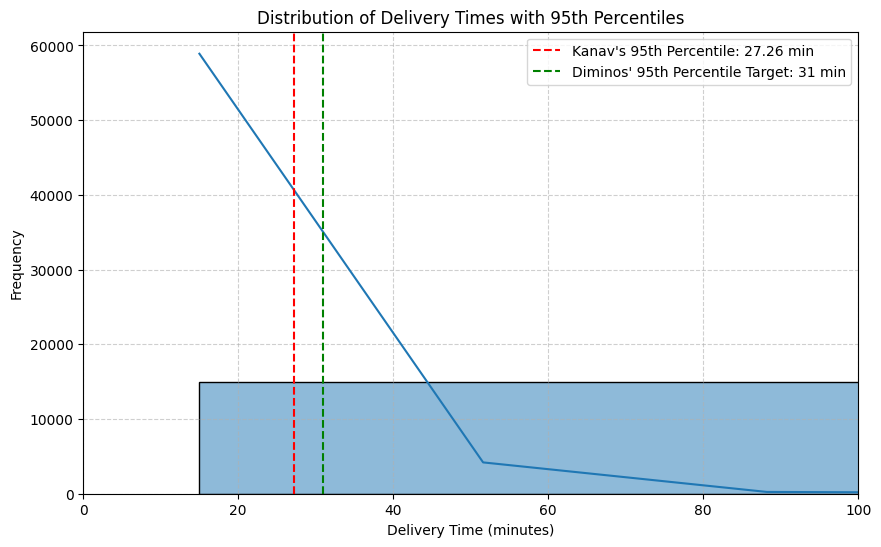

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['delivery_time'], bins=50, kde=True)

plt.axvline(x=delivery_time_95th, color='red', linestyle='--', label=f"Kanav's 95th Percentile: {delivery_time_95th:.2f} min")
plt.axvline(x=31, color='green', linestyle='--', label="Diminos' 95th Percentile Target: 31 min")

plt.title('Distribution of Delivery Times with 95th Percentiles')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.xlim(0, 100)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Most deliveries happen quickly**

**A small number of orders take very long**

In [31]:
delivery_time_frequency = df['delivery_time'].apply(lambda x: int(x)).value_counts().sort_index()
delivery_time_frequency.head(10)

,count
delivery_time,
15,8405
16,2466
17,1163
18,692
19,441
20,292
21,231
22,168
23,124


In [28]:
percentage_within_31_mins = (len(df[df['delivery_time'] <= 31]) / len(df)) * 100

print(f"Percentile of orders delivered within 31 minutes: {percentage_within_31_mins:.2f}%")

Percentile of orders delivered within 31 minutes: 96.29%


**Kanav maintained his business much efficient as per franchise rules , he even maintained 96.2 percentile deliveries with in 31 minutes when franchise wants about 95 percentile**

**His performance is strong, and no major operational improvements are required at this stage.**